# Artificial Neural Networks — A Hands-On Introduction

**Goal:** By the end of this notebook you will be able to:
1. Describe what an artificial neuron is and how neurons combine into a network.
2. Implement forward propagation and backpropagation **from scratch** in NumPy.
3. Train a network on real data and visualise what it has learned.
4. Use a high-level library (`scikit-learn`) to solve the same problem with one line.
5. Recognise how design choices (layers, neurons, activations, learning rate) affect performance.



## 0.  Setup — self-configuring environment

The cell below checks whether the packages we need are installed and installs anything that is missing. It only has to run once.

In [5]:
# Self-configuring: install any missing dependencies, then import everything.
import importlib, subprocess, sys

REQUIRED = {
    "numpy":        "numpy",
    "matplotlib":   "matplotlib",
    "sklearn":      "scikit-learn",   # import name -> pip name
}

def _ensure(pkg_import, pkg_pip):
    try:
        importlib.import_module(pkg_import)
    except ImportError:
        print(f"Installing {pkg_pip} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg_pip]
        )

for imp, pip_name in REQUIRED.items():
    _ensure(imp, pip_name)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Reproducibility — same random numbers every time you re-run.
RNG_SEED = 42
np.random.seed(RNG_SEED)

# Nicer default plots
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Environment ready ✔")
print("NumPy:", np.__version__)


Environment ready ✔
NumPy: 1.19.5


## 1.  The building block: one artificial neuron

An **artificial neuron** is a tiny mathematical function loosely inspired by biological neurons.
Given an input vector $\mathbf{x} = (x_1, x_2, \dots, x_n)$, the neuron computes:

$$
z \;=\; w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b
\;=\; \mathbf{w}^\top \mathbf{x} + b
$$

$$
a \;=\; \sigma(z)
$$

where

- $\mathbf{w}$ are the **weights** (one per input) — they say *how important* each input is,
- $b$ is the **bias** — a constant offset,
- $\sigma$ is a non-linear **activation function**,
- $a$ is the neuron's **output** (its "activation").

A neuron is therefore: **weighted sum → non-linearity**. That's it.


In [8]:
def neuron(x, w, b, activation):
    """A single artificial neuron.

    Parameters
    ----------
    x : array-like, shape (n,)        inputs
    w : array-like, shape (n,)        weights
    b : float                         bias
    activation : callable             e.g. sigmoid, relu

    Returns
    -------
    a : float                         the neuron's output
    """
    z = np.dot(w, x) + b      # weighted sum
    return activation(z)      # non-linearity


# Try it out: a neuron with two inputs that acts like a simple AND gate.
def step(z):                       # the simplest activation: 0 or 1
    return (z >= 0).astype(float)

w_and = np.array([1.0, 1.0])       # both inputs matter equally
b_and = -1.5                       # threshold: need x1 + x2 >= 1.5

print(" x1 x2 | output")
print("-------|-------")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    out = neuron(np.array(x), w_and, b_and, step)
    print(f"  {x[0]}  {x[1]}  |   {int(out)}")


 x1 x2 | output
-------|-------
  0  0  |   0
  0  1  |   0
  1  0  |   0
  1  1  |   1


👉 The neuron has just **learned the AND function** — we picked the weights and bias by hand.
Real neural networks *discover* good weights automatically. That's what training does, and it's what the rest of this notebook is about.

## 2.  Activation functions

Without a non-linearity $\sigma$, a neural network — no matter how deep — would just be a fancy linear function.
Activation functions inject the curvature that lets networks model complex relationships.

Three common choices:

| Name | Formula | Range | Used for |
|------|---------|-------|----------|
| **Sigmoid** | $\sigma(z) = \dfrac{1}{1 + e^{-z}}$ | $(0, 1)$ | binary outputs, historical |
| **Tanh**    | $\tanh(z)$ | $(-1, 1)$ | hidden layers (classic) |
| **ReLU**    | $\max(0, z)$ | $[0, \infty)$ | hidden layers (modern default) |


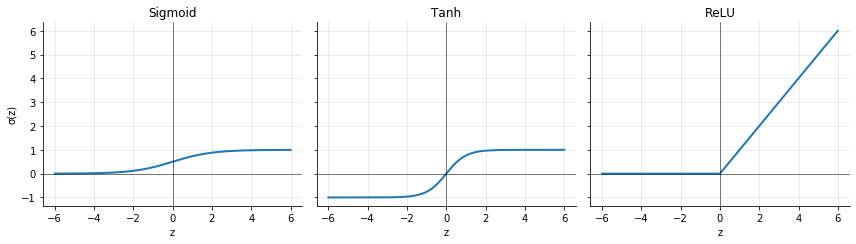

In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0.0, z)

# Visualise them side by side.
z = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for axis, fn, name in zip(ax, [sigmoid, tanh, relu], ["Sigmoid", "Tanh", "ReLU"]):
    axis.plot(z, fn(z), linewidth=2)
    axis.axhline(0, color="k", linewidth=0.5)
    axis.axvline(0, color="k", linewidth=0.5)
    axis.set_title(name)
    axis.set_xlabel("z")

ax[0].set_ylabel("σ(z)")
plt.tight_layout()
plt.show()


**Why ReLU is so popular:** it is fast to compute, its gradient is either 0 or 1 (no vanishing), and in practice it trains deep networks well. We'll use it in the hidden layers later.

## 3.  From one neuron to a whole network

Stack neurons into **layers**, and stack layers into a **network**:

```
   inputs              hidden layer            output layer
  x1 ──┐            ┌── h1 ──┐
  x2 ──┼─►  W1, b1 ─┤   h2   ├─►  W2, b2 ─►  ŷ
  x3 ──┘            └── h3 ──┘
```

For a layer with input vector $\mathbf{x}$, weight **matrix** $W$, and bias **vector** $\mathbf{b}$:

$$
\mathbf{z} = W\mathbf{x} + \mathbf{b}, \qquad \mathbf{a} = \sigma(\mathbf{z})
$$

The output of one layer becomes the input of the next.  This is called **forward propagation**.


In [16]:
# Forward propagation through a 2-layer network, by hand.
# Architecture: 2 inputs -> 3 hidden ReLU neurons -> 1 sigmoid output.

np.random.seed(0)
W1 = np.random.randn(3, 2) * 0.5    # 3 hidden neurons, 2 inputs each
b1 = np.zeros(3)
W2 = np.random.randn(1, 3) * 0.5    # 1 output neuron, 3 hidden inputs
b2 = np.zeros(1)

def forward(x):
    z1 = W1 @ x + b1            # hidden pre-activations
    a1 = relu(z1)               # hidden activations
    z2 = W2 @ a1 + b2           # output pre-activation
    a2 = sigmoid(z2)            # output (probability-like)
    return a2, (z1, a1, z2, a2) # also return intermediates for later

x = np.array([0.7, -1.2])
y_hat, _ = forward(x)
print(f"Input  : {x}")
print(f"Output : {y_hat[0]:.4f}   (interpreted as probability)")


Input  : [ 0.7 -1.2]
Output : 0.5288   (interpreted as probability)


The output is meaningless right now because the weights are random. To make it meaningful, we need to **train** the network — i.e. find weights that make the outputs match the targets we care about.

## 4.  How does a network learn? — Loss and gradient descent

### The loss function

A **loss function** measures how wrong the network's prediction is. For binary classification (output is a probability) the standard choice is **binary cross-entropy**:

$$
L(\hat{y}, y) \;=\; -\bigl[\, y\log\hat{y} + (1-y)\log(1-\hat{y}) \,\bigr]
$$

- If $y = 1$ and the network says $\hat{y} \approx 1$, the loss is near 0 (good).
- If $y = 1$ and the network says $\hat{y} \approx 0$, the loss is huge (bad).

### Gradient descent

We then adjust each weight in the direction that reduces the loss:

$$
w \;\leftarrow\; w \;-\; \eta\,\frac{\partial L}{\partial w}
$$

where $\eta$ (eta) is the **learning rate**. Computing all those partial derivatives layer by layer is exactly what **backpropagation** does — it is the chain rule from calculus, applied systematically.


## 5.  A complete neural network from scratch

Here is a small, fully-working multi-layer perceptron in pure NumPy. Read the comments — every line corresponds to an equation we discussed above.

In [21]:
class NeuralNetwork:
    """A vanilla feed-forward network: one hidden ReLU layer, sigmoid output.

    Trained with mini-batch gradient descent and binary cross-entropy.
    Kept deliberately short and unoptimised for teaching clarity.
    """

    def __init__(self, n_inputs, n_hidden, seed=0):
        rng = np.random.default_rng(seed)
        # He initialisation works well with ReLU.
        self.W1 = rng.standard_normal((n_hidden, n_inputs)) * np.sqrt(2 / n_inputs)
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.standard_normal((1, n_hidden)) * np.sqrt(2 / n_hidden)
        self.b2 = np.zeros(1)

    # ---- forward pass --------------------------------------------------
    def forward(self, X):
        # X has shape (batch, n_inputs).  We work batch-first.
        self.X  = X
        self.Z1 = X @ self.W1.T + self.b1           # (batch, n_hidden)
        self.A1 = np.maximum(0, self.Z1)            # ReLU
        self.Z2 = self.A1 @ self.W2.T + self.b2     # (batch, 1)
        self.A2 = 1 / (1 + np.exp(-self.Z2))        # sigmoid
        return self.A2.ravel()

    # ---- loss ----------------------------------------------------------
    @staticmethod
    def loss(y_pred, y_true, eps=1e-9):
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # ---- backward pass (the chain rule, written out) -------------------
    def backward(self, y_true, lr):
        m = y_true.size
        y_true = y_true.reshape(-1, 1)

        # dL/dZ2 for sigmoid + cross-entropy simplifies beautifully:
        dZ2 = (self.A2 - y_true) / m                # (batch, 1)
        dW2 = dZ2.T @ self.A1                       # (1, n_hidden)
        db2 = dZ2.sum(axis=0)

        dA1 = dZ2 @ self.W2                         # (batch, n_hidden)
        dZ1 = dA1 * (self.Z1 > 0)                   # ReLU derivative
        dW1 = dZ1.T @ self.X                        # (n_hidden, n_inputs)
        db1 = dZ1.sum(axis=0)

        # Gradient-descent update.
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    # ---- training loop -------------------------------------------------
    def fit(self, X, y, epochs=2000, lr=0.1, verbose=True):
        history = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            l = self.loss(y_pred, y)
            history.append(l)
            self.backward(y, lr)
            if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
                acc = ((y_pred > 0.5) == y).mean()
                print(f"epoch {epoch:5d}  loss={l:.4f}  acc={acc:.2%}")
        return history

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)


## 6.  Classic test: the XOR problem

XOR is the canonical example of a problem that **cannot** be solved by a single neuron — you need a hidden layer. Watch our network learn it.

epoch     0  loss=0.6694  acc=75.00%
epoch   400  loss=0.0057  acc=100.00%
epoch   800  loss=0.0021  acc=100.00%
epoch  1200  loss=0.0012  acc=100.00%
epoch  1600  loss=0.0008  acc=100.00%
epoch  2000  loss=0.0006  acc=100.00%
epoch  2400  loss=0.0005  acc=100.00%
epoch  2800  loss=0.0004  acc=100.00%
epoch  3200  loss=0.0003  acc=100.00%
epoch  3600  loss=0.0003  acc=100.00%
epoch  3999  loss=0.0003  acc=100.00%

Final predictions:
  input=[0. 0.]  target=0  predicted prob=0.001
  input=[0. 1.]  target=1  predicted prob=1.000
  input=[1. 0.]  target=1  predicted prob=1.000
  input=[1. 1.]  target=0  predicted prob=0.000


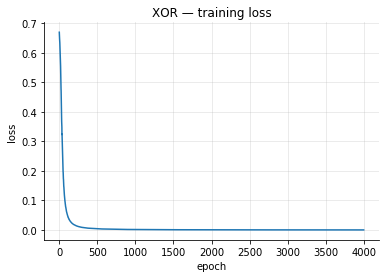

In [24]:
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

net = NeuralNetwork(n_inputs=2, n_hidden=4, seed=1)
history = net.fit(X_xor, y_xor, epochs=4000, lr=0.5)

print("\nFinal predictions:")
for x, t in zip(X_xor, y_xor):
    p = net.forward(x.reshape(1, -1))[0]
    print(f"  input={x}  target={int(t)}  predicted prob={p:.3f}")

plt.figure()
plt.plot(history)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("XOR — training loss")
plt.show()


## 7.  A real(ish) dataset: the *two moons*

`scikit-learn` ships with toy datasets perfect for visualising what a network learns. The "moons" dataset is two interleaving half-circles — not linearly separable, but easy to plot.

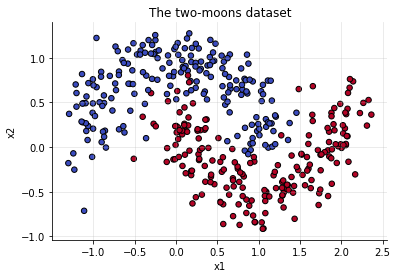

In [27]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=400, noise=0.20, random_state=RNG_SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y.astype(float), test_size=0.25, random_state=RNG_SEED
)

# Plot the raw data.
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
plt.title("The two-moons dataset"); plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


In [29]:
# Train our scratch network on it.
net = NeuralNetwork(n_inputs=2, n_hidden=16, seed=RNG_SEED)
history = net.fit(X_train, y_train, epochs=3000, lr=0.1, verbose=True)

train_acc = (net.predict(X_train) == y_train).mean()
test_acc  = (net.predict(X_test)  == y_test ).mean()
print(f"\nTrain accuracy: {train_acc:.2%}")
print(f"Test  accuracy: {test_acc:.2%}")


epoch     0  loss=0.5600  acc=74.33%
epoch   300  loss=0.2794  acc=84.33%
epoch   600  loss=0.2685  acc=87.00%
epoch   900  loss=0.2637  acc=87.00%
epoch  1200  loss=0.2598  acc=87.33%
epoch  1500  loss=0.2562  acc=87.33%
epoch  1800  loss=0.2501  acc=87.67%
epoch  2100  loss=0.2370  acc=88.67%
epoch  2400  loss=0.2129  acc=89.67%
epoch  2700  loss=0.1842  acc=92.00%
epoch  2999  loss=0.1593  acc=93.67%

Train accuracy: 93.67%
Test  accuracy: 92.00%


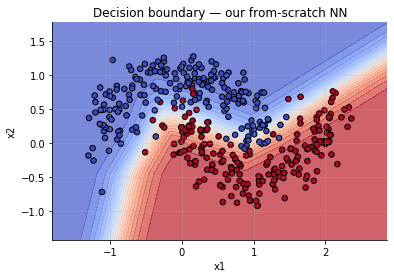

In [31]:
def plot_decision_boundary(model, X, y, title=""):
    """Colour every point of the plane by the model's prediction."""
    pad = 0.5
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

plot_decision_boundary(net, X, y, "Decision boundary — our from-scratch NN")


👀 **What you are looking at:** the colour of each pixel is the network's predicted probability that a point at that location belongs to class 1. The curvy boundary between the colours is what the network has *learned*. A linear classifier (e.g. logistic regression) could only draw a straight line here.

## 8.  The same thing with scikit-learn — one line of training code

Now that you have *implemented* the algorithm, you can use the industrial version with a clear conscience.

In [35]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(
    hidden_layer_sizes=(16,),   # one hidden layer, 16 neurons — matches ours
    activation="relu",
    solver="adam",              # a smarter optimiser than plain GD
    max_iter=3000,
    random_state=RNG_SEED,
)
clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.2%}")
print(f"Test  accuracy: {clf.score(X_test,  y_test ):.2%}")


Train accuracy: 93.00%
Test  accuracy: 92.00%


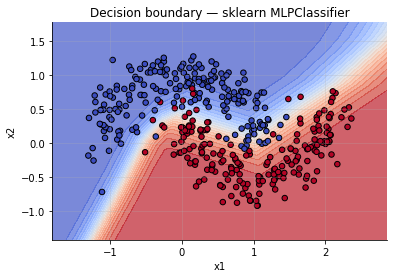

In [37]:
# Reuse our plotting helper by wrapping sklearn in a tiny adapter.
class SkAdapter:
    def __init__(self, clf): self.clf = clf
    def forward(self, X): return self.clf.predict_proba(X)[:, 1]

plot_decision_boundary(SkAdapter(clf), X, y, "Decision boundary — sklearn MLPClassifier")


## 9.  Experiment: how many hidden neurons do we actually need?

Run the cell below and look at how the decision boundary changes with the size of the hidden layer. Too few neurons → the network is too simple (**underfits**). Too many on a tiny dataset → it can memorise noise (**overfits**).

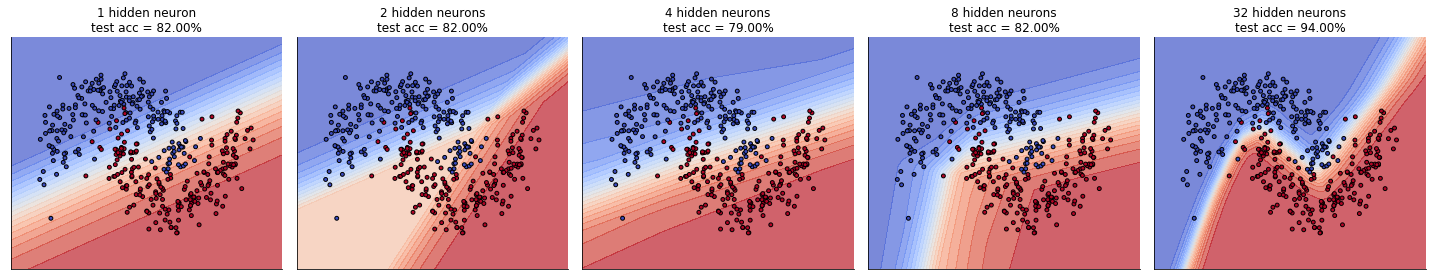

In [40]:
sizes = [1, 2, 4, 8, 32]
fig, axes = plt.subplots(1, len(sizes), figsize=(4 * len(sizes), 4))

pad = 0.5
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, n_hidden in zip(axes, sizes):
    model = MLPClassifier(hidden_layer_sizes=(n_hidden,),
                          activation="relu",
                          max_iter=3000,
                          random_state=RNG_SEED).fit(X_train, y_train)
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"{n_hidden} hidden neuron{'s' if n_hidden > 1 else ''}\ntest acc = {model.score(X_test, y_test):.2%}")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


## 10.  Exercises

Try these in new cells below. Solutions are short — usually one or two changes to existing code.

1. **Activation surgery.** Replace the hidden-layer ReLU in `NeuralNetwork` with `tanh`. Does it still learn XOR? How do the gradients change?
2. **The learning rate.** Re-run the moons training with `lr = 0.001`, `0.1`, `1.0`, and `10.0`. Plot the four loss curves on the same axes and comment.
3. **More moons.** Generate `make_moons(noise=0.4)` — much noisier — and see how much accuracy drops. Can you recover it with a wider network?
4. **Three classes.** Replace `make_moons` with `make_blobs(centers=3)`. You'll need to change the output layer from 1 neuron + sigmoid to 3 neurons + *softmax*, and the loss to *categorical* cross-entropy. (`MLPClassifier` does all this automatically — try it first with sklearn, then think about what would need to change in our scratch class.)
5. **Deeper, not just wider.** `MLPClassifier(hidden_layer_sizes=(8, 8, 8))` gives a 3-hidden-layer network. Compare the decision boundaries of `(64,)` versus `(8, 8, 8)` on the moons. Same total parameters, very different inductive bias.

### Reflection questions

- Why does a network with **no** hidden layer fail on XOR?
- What would happen if every weight were initialised to *zero*?
- Why do we use mini-batches in practice instead of feeding the whole dataset at once?

---

## Further reading

- 3Blue1Brown's *Neural Networks* video series (YouTube) — the best visual intuition you can get for free.
- Michael Nielsen, *Neural Networks and Deep Learning*, neuralnetworksanddeeplearning.com — free online book that goes deeper into the maths.
- Goodfellow, Bengio & Courville, *Deep Learning* (MIT Press) — the standard graduate textbook, also free online.
- The PyTorch and TensorFlow tutorials, once you want to move beyond toy datasets.
